In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import mido
from delta_3d_lookup import *
from bass_to_bass_mm import *
import IPython.display as ipd

In [2]:
#get the lookup table
#copied this from the delta_3d_lookup.py file

train_dir = os.path.join('jsb_chorales', 'train')
lookup_table = get_delta_3d_lookup(train_dir)

bass_to_bass_transition = train_bass_to_bass_markov(train_dir)

Parsing CSVs: 100%|██████████| 229/229 [00:00<00:00, 1959.48song/s]


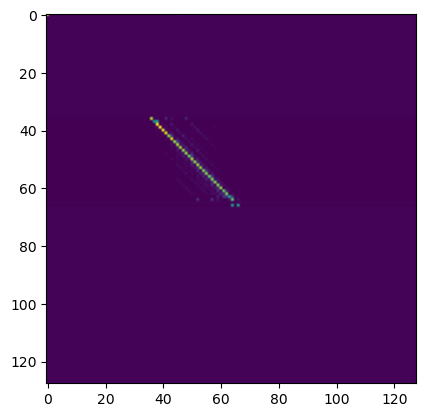

In [3]:
plt.imshow(bass_to_bass_transition)
plt.show()

In [4]:
def get_bassline(lookup_table, A, soprano_input, l=1):
    """
    Inputs
      - lookup_table: a matrix containing log probabilities P(delta | soprano_{n-1}, bass_n) of size (128, 128, 2*num_semitones+2), indexed (bass, prev_soprano, delta)
      - A: an 128 x 128 matrix specifying transitions of bass notes between moments in time
      - soprano input -- a 1d array of soprano midi notes
        
    Outputs
      - B_est: the supporting bassline
    """
    ### INSERT CODE BELOW ###
    
    #grab dimensions and initialize cumulative cost matrix
    N = np.size(soprano_input)
    M = 128

    #make sure A and pi has no zeros
    A = np.clip(A, 1E-9, 1) # we don't even have to renormalize?

    D = np.zeros((M, N))
    B = np.zeros((M, N))

    #initialize probabilities
    D[:, 0] = np.sum(lookup_table[:, :, :], axis=(1,2)) #should add log(P(O_1 | S_1)) term
    #just writes total probability of being in that bass note (sums over soprano and delta dimensions)

    #lookup table is indexed (bass, prev_soprano, delta)
    #walk through the matrix
    for j in range(1, N):
      delta = soprano_input[j] - soprano_input[j-1]
      for i in range(M):
        D[i, j] = np.max(D[:, j-1] + np.log(A[:, i])+ l*lookup_table[:, int(soprano_input[j-1]), delta_2_index(delta)])
        B[i,j] = np.argmax(D[:, j-1] + np.log(A[:, i])+ l*lookup_table[:, int(soprano_input[j-1]), delta_2_index(delta)])

        #best_index = int(B[i,j])
        #print(np.log(A[best_index, i]), l*lookup_table[best_index, int(soprano_input[j-1]), delta_2_index(delta)])
  

    B_est = np.zeros(N, dtype = int)
    endpoint = np.argmax(D[:, -1])
    B_est[-1] = endpoint

    for i in range(N-1)[::-1]:
      B_est[i] = B[int(B_est[i+1]), i+1]

    return B_est

In [ ]:
path = os.path.join('jsb_chorales', 'train', 'chorale_005.csv')
S, _, _, _ = csv_to_tracks(path)

B = get_bassline(lookup_table, bass_to_bass_transition, S, l=1)

In [33]:
B

array([54, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56,
       56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 57,
       57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57,
       57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 57, 56,
       56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56,
       56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 56, 54, 54, 54,
       54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54,
       54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54,
       54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54,
       54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54,
       54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54,
       54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54,
       56, 56, 56, 56, 56, 56, 56, 56])

In [16]:
#if you want to output to a midi file
def arrays_to_midi(tracks_tuple, output_filename="output.mid", bpm=120):
    """
    Converts a tuple of 1D arrays (MIDI notes) into a MIDI file.
    
    Args:
        tracks_tuple: Tuple of 1D arrays/lists containing MIDI note numbers.
                      Use 0 or None for silence/rests.
        output_filename: Name of the file to save.
        bpm: Beats per minute.
    """
    # 4 PPQ means each array index is a 16th note (in 4/4 time)
    ppq = 4 
    mid = mido.MidiFile(ticks_per_beat=ppq)
    
    # Calculate microseconds per beat for the tempo track
    tempo = mido.bpm2tempo(bpm)
    
    for track_data in tracks_tuple:
        track = mido.MidiTrack()
        mid.tracks.append(track)
        
        # Optional: Add tempo to the first track
        if mid.tracks.index(track) == 0:
            track.append(mido.MetaMessage('set_tempo', tempo=tempo))

        last_note = None
        ticks_since_last_event = 0

        for note in track_data:
            # Case 1: Note change or Note ending
            if note != last_note:
                # If a note was playing, turn it off
                if last_note is not None and last_note > 0:
                    track.append(mido.Message('note_off', note=int(last_note), 
                                         velocity=64, time=ticks_since_last_event))
                    ticks_since_last_event = 0
                
                # If the new value is a note, turn it on
                if note is not None and note > 0:
                    track.append(mido.Message('note_on', note=int(note), 
                                         velocity=64, time=ticks_since_last_event))
                    ticks_since_last_event = 0
                
                last_note = note
            
            # Increment time (1 tick per array index)
            ticks_since_last_event += 1

        # Clean up: Close the last note if the array ends while playing
        if last_note is not None and last_note > 0:
            track.append(mido.Message('note_off', note=int(last_note), 
                                 velocity=64, time=ticks_since_last_event))

    mid.save(output_filename)
    print(f"Successfully saved to {output_filename}")

arrays_to_midi((S, B))

Successfully saved to output.mid


In [17]:
import numpy as np
import IPython.display as ipd

def midi_arrays_to_ipd(tracks_tuple, bpm=120, sample_rate=44100):
    """
    Synthesizes MIDI arrays where repeated consecutive notes are held 
    as a single continuous tone.
    """
    step_duration = (60.0 / bpm) / 4
    num_steps = max(len(t) for t in tracks_tuple)
    
    total_samples = int(num_steps * step_duration * sample_rate)
    master_buffer = np.zeros(total_samples)

    def midi_to_freq(note):
        if note is None or note <= 0: return 0
        return 440.0 * (2.0 ** ((note - 69) / 12.0))

    for track in tracks_tuple:
        i = 0
        while i < len(track):
            note = track[i]
            freq = midi_to_freq(note)
            
            if freq > 0:
                # 1. Figure out how long this note is held
                start_step = i
                while i < len(track) and track[i] == note:
                    i += 1
                end_step = i
                
                # 2. Calculate the continuous duration
                hold_count = end_step - start_step
                note_duration = hold_count * step_duration
                
                # 3. Synthesize the long "held" wave
                t_held = np.linspace(0, note_duration, int(note_duration * sample_rate), False)
                wave = np.sin(2 * np.pi * freq * t_held)
                
                # 4. Apply envelope only at the start and end of the hold
                fade_len = min(int(sample_rate * 0.005), len(wave) // 2) 
                envelope = np.ones_like(wave)
                if fade_len > 0:
                    envelope[:fade_len] = np.linspace(0, 1, fade_len)
                    envelope[-fade_len:] = np.linspace(1, 0, fade_len)
                
                # 5. Mix into master buffer
                start_idx = int(start_step * step_duration * sample_rate)
                end_idx = start_idx + len(wave)
                
                # Ensure we don't overshoot the buffer due to rounding
                master_buffer[start_idx:end_idx] += (wave * envelope * 0.2)
            else:
                # It's a rest, just move to the next index
                i += 1

    return ipd.Audio(master_buffer, rate=sample_rate)

midi_arrays_to_ipd((S, B), bpm=120)